In [2]:
!pip install pandas numpy matplotlib scikit-learn xgboost interpret shap seaborn openpyxl

     ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
     ---------- ----------------------------- 1.0/4.0 MB 15.6 MB/s eta 0:00:01
     ---------------------------------------- 4.0/4.0 MB 9.4 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   -- ------------------------------------- 3.7/48.9 MB 17.5 MB/s eta 0:00:03
   ----- ---------------------------------- 7.3/48.9 MB 17.7 MB/s eta 0:00:03
   -------- ------------------------------- 10.5/48.9 MB 16.7 MB/s eta 0:00:03
   ----------- ---------------------------- 13.6/48.9 MB 16.1 MB/s eta 0:00:03
   -------------- ------------------------- 18.1/48.9 MB 17.2

Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
from sklearn.model_selection import GroupShuffleSplit

print("Libraries imported successfully.")

Libraries imported successfully.


Loading the dataset

In [4]:
df = pd.read_csv("dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


 Inspecting the dataset

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Rows: 101766
Columns: 50

Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


Target Variable

In [8]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [10]:
df["readmitted"].value_counts(normalize=True) * 100 #percentage value

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

In [11]:
df["target"] = (df["readmitted"] == "<30").astype(int) #creating the target

In [12]:
df["target"].value_counts()

target
0    90409
1    11357
Name: count, dtype: int64

In [13]:
df["target"].value_counts(normalize=True) * 100

target
0    88.840084
1    11.159916
Name: proportion, dtype: float64

Checking patients and repeated encounters

In [14]:
print("Total encounters:", len(df))
print("Unique patients:", df["patient_nbr"].nunique())

Total encounters: 101766
Unique patients: 71518


In [15]:
encounters_per_patient = df.groupby("patient_nbr").size()

print(encounters_per_patient.describe())

count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
dtype: float64


In [17]:
print(
    "Patients with more than one encounter:",
    (encounters_per_patient > 1).sum()
)

Patients with more than one encounter: 16773


Removeing identifiers

In [18]:
groups = df["patient_nbr"].copy()

In [19]:
df = df.drop(columns=["encounter_id", "patient_nbr"])

Handling missing values

In [20]:
missing_values = (df == "?").sum()

In [21]:
missing_values[missing_values > 0].sort_values(
    ascending=False
)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [22]:
df = df.replace("?", np.nan)

In [31]:
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,target
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,Yes,NO,0
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,Steady,No,No,No,No,No,Ch,Yes,NO,0
5,Caucasian,Male,[50-60),NaN,2,1,2,3,NaN,NaN,...,Steady,No,No,No,No,No,No,Yes,>30,0
6,Caucasian,Male,[60-70),NaN,3,1,2,4,NaN,NaN,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


In [26]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

Defining the adult cohort

In [27]:
print(df["age"].value_counts().sort_index())

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


In [28]:
df = df[~df["age"].isin(["[0-10)", "[10-20)"])].copy()

In [29]:
print("Remaining records:", len(df))

Remaining records: 100914


In [30]:
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True) * 100)

target
0    89600
1    11314
Name: count, dtype: int64
target
0    88.788473
1    11.211527
Name: proportion, dtype: float64


In [32]:
print(df["race"].value_counts(dropna=False))
print(df["gender"].value_counts(dropna=False))
print(df["age"].value_counts(dropna=False).sort_index())

race
Caucasian          75525
AfricanAmerican    18985
NaN                 2263
Hispanic            2012
Other               1492
Asian                637
Name: count, dtype: int64
gender
Female             54223
Male               46688
Unknown/Invalid        3
Name: count, dtype: int64
age
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


Target visualisation

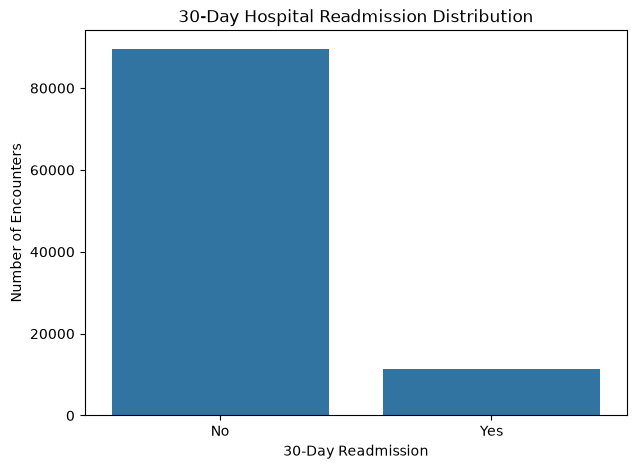

In [78]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="target"
)

plt.title("30-Day Hospital Readmission Distribution")
plt.xlabel("30-Day Readmission")
plt.ylabel("Number of Encounters")
plt.xticks([0, 1], ["No", "Yes"]) #changing label name

plt.show()

In [34]:
print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Dataset shape: (100914, 49)

Target distribution:
target
0    89600
1    11314
Name: count, dtype: int64

Missing values:
weight                      97740
max_glu_serum               95583
A1Cresult                   84339
medical_specialty           49693
payer_code                  39646
race                         2263
diag_3                       1106
diag_2                        222
diag_1                         21
time_in_hospital                0
admission_source_id             0
num_procedures                  0
num_lab_procedures              0
admission_type_id               0
discharge_disposition_id        0
age                             0
gender                          0
number_inpatient                0
number_emergency                0
number_outpatient               0
dtype: int64


In [35]:
X = df.drop(columns=["target"])

y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100914, 48)
y shape: (100914,)


In [79]:
groups = groups.loc[X.index].copy() #patient IDs correspond to the correct row

In [39]:
print("X:", len(X))
print("y:", len(y))
print("groups:", len(groups))

X: 100914
y: 100914
groups: 100914


In [81]:
#patient level splitting to remove the same patient appearing in both training and testing sets
from sklearn.model_selection import GroupShuffleSplit

#creating the splitter
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

In [45]:
print("Training records:", X_train.shape)
print("Testing records:", X_test.shape)

Training records: (80771, 48)
Testing records: (20143, 48)


In [46]:
overlap = set(groups_train).intersection(set(groups_test))

print("Patients appearing in both train and test:", len(overlap)) #checking for any overlapping patients

Patients appearing in both train and test: 0


In [47]:
df.head(2)

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,target
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,Yes,NO,0
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,Up,No,No,No,No,No,Ch,Yes,NO,0


Finding categroical and numerical variables

In [50]:
df.dtypes

race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide                 str
glipizide                     str
glyburide     

In [51]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64"]
).columns.tolist()


print("\nCategorical variables:")
print(categorical_features)

print("\nNumerical variables:")
print(numerical_features)


Categorical variables:
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Numerical variables:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


In [53]:
X_train = X_train.drop(columns=["readmitted"])
X_test = X_test.drop(columns=["readmitted"])

In [59]:
print("readmitted" in X_train.columns)

False


Creating preprosessing pipeline

In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer #handling missing values
from sklearn.pipeline import Pipeline

#pipeline for numeric variables
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), #replacing with median of the variable
    ("scaler", StandardScaler())
])

#pipeline for categorical vairables
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), #replacing with the most frequent category
    ("onehot", OneHotEncoder(handle_unknown="ignore")) #converts categories into binary
])

#combing two pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Training the Penalised Logistic Regression

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000, #number of iterations
        random_state=42
    ))
])

In [69]:
logistic_model.fit(X_train, y_train)

print("Logistic regression training completed.")

Logistic regression training completed.
